In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_path = '/content/drive/MyDrive/case_study_2/data/elektrik_veri_hashed.xlsx'
xls = pd.ExcelFile(file_path)

In [4]:
df_tahsilat = pd.read_excel(xls, sheet_name='Tahsilat')
df_tahsilat_1 = pd.read_excel(xls, sheet_name='Tahsilat 1')
df_tahakkuk = pd.read_excel(xls, sheet_name='Tahakkuk')
df_tahakkuk_1 = pd.read_excel(xls, sheet_name='Tahakkuk 1')
df_tahakkuk_2 = pd.read_excel(xls, sheet_name='Tahakkuk 2')

In [5]:
df_tahakkuk_tumu = pd.concat([df_tahakkuk, df_tahakkuk_1, df_tahakkuk_2])

In [6]:
print(df_tahsilat.shape)
print(df_tahsilat_1.shape)
print(df_tahakkuk_tumu.shape)

(636993, 9)
(917632, 22)
(1185698, 10)


## İlçe Karşılaştırma Analizi

**Problem:** İlçeler arasında tüketim farkı var, bu farkın sebebi ne olabilir?

**Hipotezler:**
- H1: Sebep hesap sınıfı dağılımı olabilir (bir ilçede ticari/tarımsal müşteri oranı daha fazla olabilir)
- H2: Sebep mevsimsel/iklimsel farklar olabilir

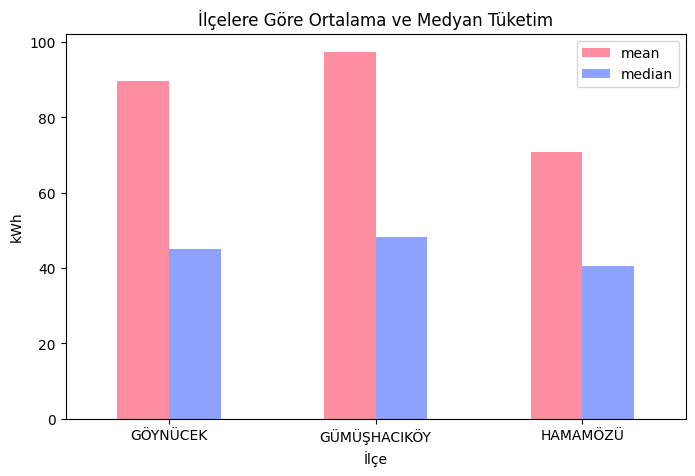

In [22]:
ilce_ozet[['mean', 'median']].plot(kind='bar', figsize=(8, 5), color=['#FF8DA1', '#8DA1FF'])
plt.title('İlçelere Göre Ortalama ve Medyan Tüketim')
plt.xlabel('İlçe')
plt.ylabel('kWh')
plt.xticks(rotation=0)
plt.savefig('ilce_karsilastirma_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
#  İlçe özet tablosu
ilce_ozet = df_tahakkuk_tumu.groupby('ilce')['kwh'].agg(['mean', 'median', 'std', 'count'])
ilce_ozet['musteri_sayisi'] = df_tahakkuk_tumu.groupby('ilce')['sozlesme_hesap_no'].nunique()
print(ilce_ozet)



                   mean  median          std   count  musteri_sayisi
ilce                                                                
GÖYNÜCEK      89.669891   45.09   742.276369  295223            7128
GÜMÜŞHACIKÖY  97.336632   48.31  1077.758336  765657           18190
HAMAMÖZÜ      70.874619   40.56   389.217875  124818            2981


Ortalama tüketime göre Gümüşhacıköy en yüksek, sonra Göynücek, en düşük Hamamözü .
Ama std çok yüksek, özellikle Gümüşhacıköy'de.Bu outlier'ların ortalamayı yukarı çektiğini gösteriyor.
Medyana bakınca sıralama aynı kalıyor ama fark küçülüyor. Medyan burada daha güvenilir.

In [8]:
# 2) Mesken oranı
mesken_sayisi = df_tahakkuk_tumu[df_tahakkuk_tumu['Hesap Sınıfı'] == 'Mesken'].groupby('ilce').size()
toplam_sayisi = df_tahakkuk_tumu.groupby('ilce').size()
mesken_orani = mesken_sayisi / toplam_sayisi * 100
print(mesken_orani)


ilce
GÖYNÜCEK        87.302819
GÜMÜŞHACIKÖY    85.963950
HAMAMÖZÜ        88.674710
dtype: float64


Hiptez 1'i test sonucu: mesken oranı üç ilçede de birbirine çok yakın (%86-89 arası).Yani hesap sınıfı dağılımı ilçeler arasında neredeyse aynı, tüketim farkının sebebi bu değil. H1 reddedildi.

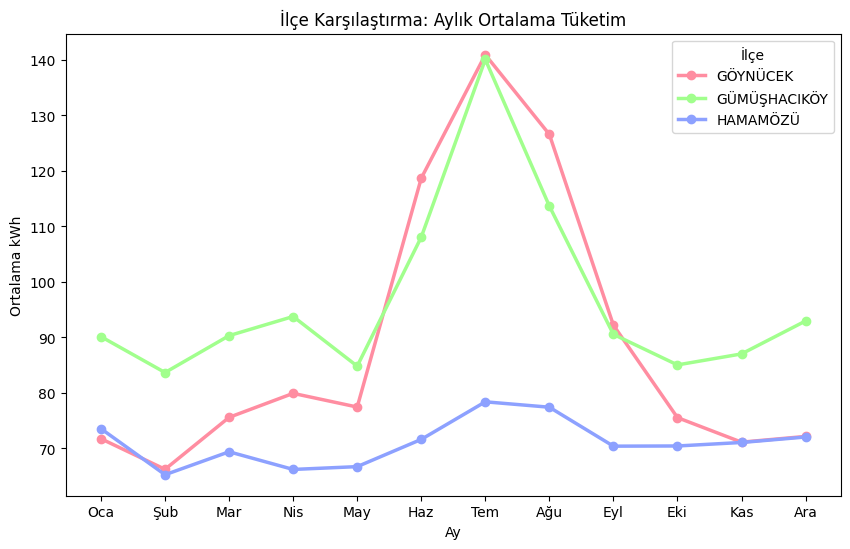

In [17]:

# 3) Mevsimsel trend
df_tahakkuk_tumu['mali_yil_donem'] = pd.to_datetime(df_tahakkuk_tumu['mali_yil_donem'])
df_tahakkuk_tumu['ay'] = df_tahakkuk_tumu['mali_yil_donem'].dt.month
aylik_ortalama = df_tahakkuk_tumu.pivot_table(index='ay', columns='ilce', values='kwh', aggfunc='mean')

renkler = ['#FF8DA1', '#A1FF8D', '#8DA1FF']
ay_isimleri = ['Oca', 'Şub', 'Mar', 'Nis', 'May', 'Haz', 'Tem', 'Ağu', 'Eyl', 'Eki', 'Kas', 'Ara']
aylik_ortalama.plot(kind='line', figsize=(10, 6), color=renkler, marker='o', linewidth=2.5)
plt.title('İlçe Karşılaştırma: Aylık Ortalama Tüketim')
plt.xlabel('Ay')
plt.ylabel('Ortalama kWh')
plt.xticks(ticks=range(1, 13), labels=ay_isimleri)
plt.legend(title='İlçe')
plt.savefig('ilce_karsilastirma_mevsimsel.png', dpi=150, bbox_inches='tight')
plt.show()

Hipotez 2  test sonucu : grafikte Gümüşhacıköy ve Göynücek yaz aylarında belirgin şekilde artıyor, Hamamözü ise düz kalıyor.
Bu Hipotez 2'yi destekliyor.

**Sonuç :** Tüketim farkının kaynağı müşteri tipi değil, mevsimsel davranış — muhtemelen coğrafi/iklimsel bir sebep var.

**İş önerisi:** Gümüşhacıköy ve Göynücek için yaz aylarına özel kapasite planlaması yapılabilir. Hamamözü'nün düşük ve durağan
tüketim profili için farklı bir tarife stratejisi düşünülebilir.

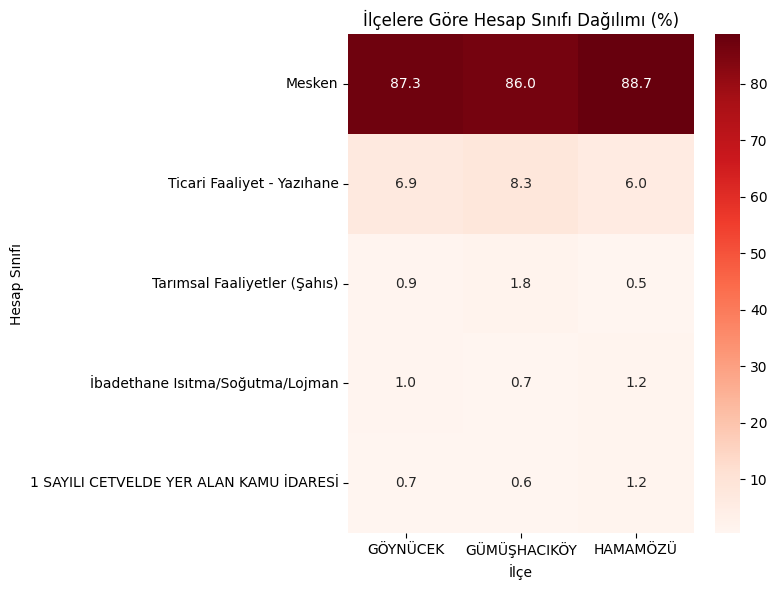

In [23]:
hesap_ilce_pivot = pd.crosstab(df_tahakkuk_tumu['Hesap Sınıfı'], df_tahakkuk_tumu['ilce'], normalize='columns') * 100
en_buyuk_5 = df_tahakkuk_tumu['Hesap Sınıfı'].value_counts().head(5).index
hesap_ilce_pivot = hesap_ilce_pivot.loc[en_buyuk_5]

plt.figure(figsize=(8, 6))
sns.heatmap(hesap_ilce_pivot.round(1), annot=True, fmt='.1f', cmap='Reds')
plt.title('İlçelere Göre Hesap Sınıfı Dağılımı (%)')
plt.xlabel('İlçe')
plt.ylabel('Hesap Sınıfı')
plt.tight_layout()
plt.savefig('hesap_sinifi_ilce_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

En büyük 5 hesap sınıfının ilçelere göre dağılımına baktım. Mesken oranı üç ilçede de birbirine çok yakın çıktı,
diğer sınıflar da küçük ve benzer paylara sahip. Bu, mesken_orani tablosunda gördüğümüzü görsel olarak doğruluyor.Hesap sınıfı dağılımı ilçeler arası fark yaratmıyor.

## Müşteri Segmentasyonu

**Problem:** Müşterileri tüketim ve ödeme davranışına göre gruplara ayırıp her grup için ayrı strateji geliştirmek.

**Çözüm:** Tüketim miktarı ile ödeme güvenilirliği arasında bir ilişki olabilir.

In [18]:
# Müşteri bazlı ortalama tüketim
musteri_tuketim = df_tahakkuk_tumu.groupby('sozlesme_hesap_no')['kwh'].mean()

# Müşteri bazlı geç ödeme oranı
gec_sutunlari = ['Son Ödeme (1)', 'Son Ödeme (2)', 'Son Ödeme (3)', 'Son Ödeme (4)', 'Son Ödeme (5)',
                  'Son Ödeme (6-10)', 'Son Ödeme (10-20)', 'Son Ödeme (20-30)', 'Son Ödeme (30-60)',
                  'Son Ödeme (60-90)', 'Son Ödeme (90-120)', 'Son Ödeme (120-150)', 'Son Ödeme (150-180)',
                  'Son Ödeme (180+)']
df_tahsilat_1['gec_mi'] = df_tahsilat_1[gec_sutunlari].notna().any(axis=1)
musteri_gec_orani = df_tahsilat_1.groupby('Söz.hsp.(bağımsız)')['gec_mi'].mean()

# İkisini birleştir
musteri_ozet = pd.DataFrame({
    'ortalama_kwh': musteri_tuketim,
    'gec_odeme_orani': musteri_gec_orani
}).dropna()

print(musteri_ozet.shape)



(27391, 2)


In [19]:
# Eşik değerler: medyan üstü = yüksek, altı = düşük
kwh_esik = musteri_ozet['ortalama_kwh'].median()
gec_esik = musteri_ozet['gec_odeme_orani'].median()

def segment_belirle(satir):
    if satir['ortalama_kwh'] >= kwh_esik and satir['gec_odeme_orani'] < gec_esik:
        return 'Değerli Sadık Müşteri'
    elif satir['ortalama_kwh'] >= kwh_esik and satir['gec_odeme_orani'] >= gec_esik:
        return 'Riskli Yüksek Tüketici'
    elif satir['ortalama_kwh'] < kwh_esik and satir['gec_odeme_orani'] < gec_esik:
        return 'Sadık Düşük Tüketici'
    else:
        return 'Riskli Düşük Tüketici'

musteri_ozet['segment'] = musteri_ozet.apply(segment_belirle, axis=1)

print(musteri_ozet['segment'].value_counts())
print(musteri_ozet.groupby('segment')[['ortalama_kwh', 'gec_odeme_orani']].mean())

segment
Riskli Düşük Tüketici     7355
Değerli Sadık Müşteri     7155
Riskli Yüksek Tüketici    6541
Sadık Düşük Tüketici      6340
Name: count, dtype: int64
                        ortalama_kwh  gec_odeme_orani
segment                                              
Değerli Sadık Müşteri     148.584903         0.040109
Riskli Düşük Tüketici      18.181595         0.561091
Riskli Yüksek Tüketici    211.739715         0.534480
Sadık Düşük Tüketici       19.033133         0.027997


Medyan eşiğine göre 4 segment oluşturdum. Segment büyüklükleri birbirine yakın çıktı (6300-7400 arası), yani hiçbiri baskın değil.
Ödeme davranışı segmentler arasında çok keskin ayrılıyor: sadık gruplarda geç ödeme oranı %3-4, riskli gruplarda %53-56.
Ortada kalan pek yok, ya çok güvenilir ya çok riskli.

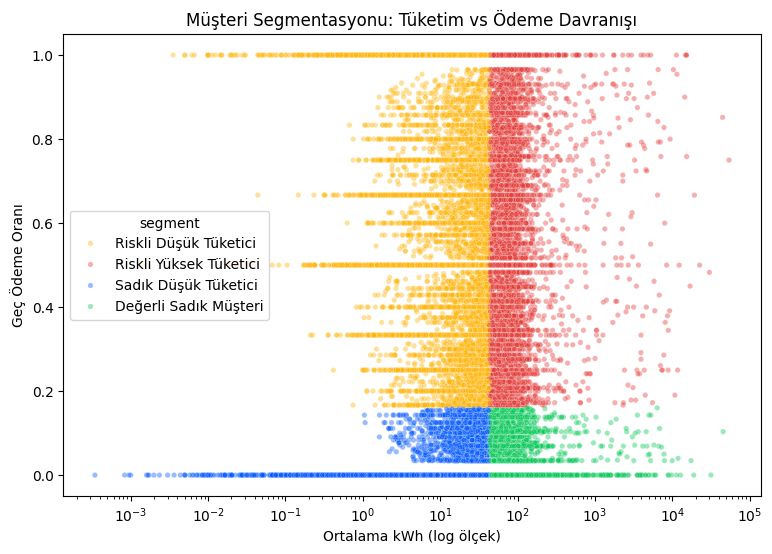

In [13]:
renk_haritasi = {
    'Değerli Sadık Müşteri': '#00C853',
    'Sadık Düşük Tüketici': '#0057FF',
    'Riskli Yüksek Tüketici': '#E53935',
    'Riskli Düşük Tüketici': '#FFB300'
}

plt.figure(figsize=(9, 6))
sns.scatterplot(data=musteri_ozet, x='ortalama_kwh', y='gec_odeme_orani', hue='segment',
                 palette=renk_haritasi, alpha=0.4, s=15)
plt.xscale('log')
plt.xlabel('Ortalama kWh (log ölçek)')
plt.ylabel('Geç Ödeme Oranı')
plt.title('Müşteri Segmentasyonu: Tüketim vs Ödeme Davranışı')
plt.savefig('musteri_segmentasyonu.png', dpi=150, bbox_inches='tight')
plt.show()

**Sonuç:** Tüketim miktarı tek başına ödeme güvenilirliğini belirlemiyor.Hem yüksek hem düşük tüketen müşteriler arasında riskli grup var.

**İş önerisi:** Riskli Yüksek Tüketici grubu (ort. 211 kWh, %53 geç ödeme) en kritik grup.Hem yüksek gelir hem yüksek risk,
öncelikli takip edilmeli. Değerli Sadık Müşteri grubuna sadakat/otomatik ödeme talimatı teşvik edilebilir. Riskli Düşük
Tüketici grubunda tutar küçük olduğu için SMS hatırlatma gibi düşük maliyetli yöntemler yeterli olabilir.

## BONUS: Tahsilat Performans Analizi

**Problem:** Geç ödemeyi hangi faktörler etkiliyor?

**Hipotezler:**
- H1: Hesap sınıfı geç ödeme oranını etkileyebilir
- H2: İlçe geç ödeme oranını etkileyebilir
- H3: Fatura tutarı büyüdükçe geç ödeme oranı artabilir

In [24]:
# Hipotez 1: Hesap sınıfına göre geç ödeme oranı ne?
hesap_sinifi_gec = df_tahsilat_1.groupby('Hesap Sınıfı')['gec_mi'].agg(['mean', 'count'])
hesap_sinifi_gec = hesap_sinifi_gec[hesap_sinifi_gec['count'] >= 500]
hesap_sinifi_gec = hesap_sinifi_gec.sort_values('mean', ascending=False)
print(hesap_sinifi_gec)

                                             mean   count
Hesap Sınıfı                                             
Belediye                                 0.597275    1321
Köy İçme Suyu Temini ve Dağıtımı Tesisi  0.556732    1322
Tarımsal Faaliyetler (Kooperatif)        0.525296     929
Büyükbaş-Küçükbaş Hayvancılık            0.435326    1121
Şantiye ve Geçici Aboneler               0.367353    6751
Ticari Faaliyet - Yazıhane               0.311167   70001
1 SAYILI CETVELDE YER ALAN KAMU İDARESİ  0.288808    3833
Tarımsal Faaliyetler (Şahıs)             0.272105    9636
Resmi Daire                              0.269430     965
Mesken                                   0.266910  797842
Şehit Aileleri ve Gaziler                0.225618    2912
İbadethane Isıtma/Soğutma/Lojman         0.222470    7637
İbadethane Aydınlatma                    0.209132    5322
Bina Ort Kul (Asn,Hidr,Kapıcı Dai vb.)   0.208063    4167
Süt Toplama Merkezi                      0.062500     608


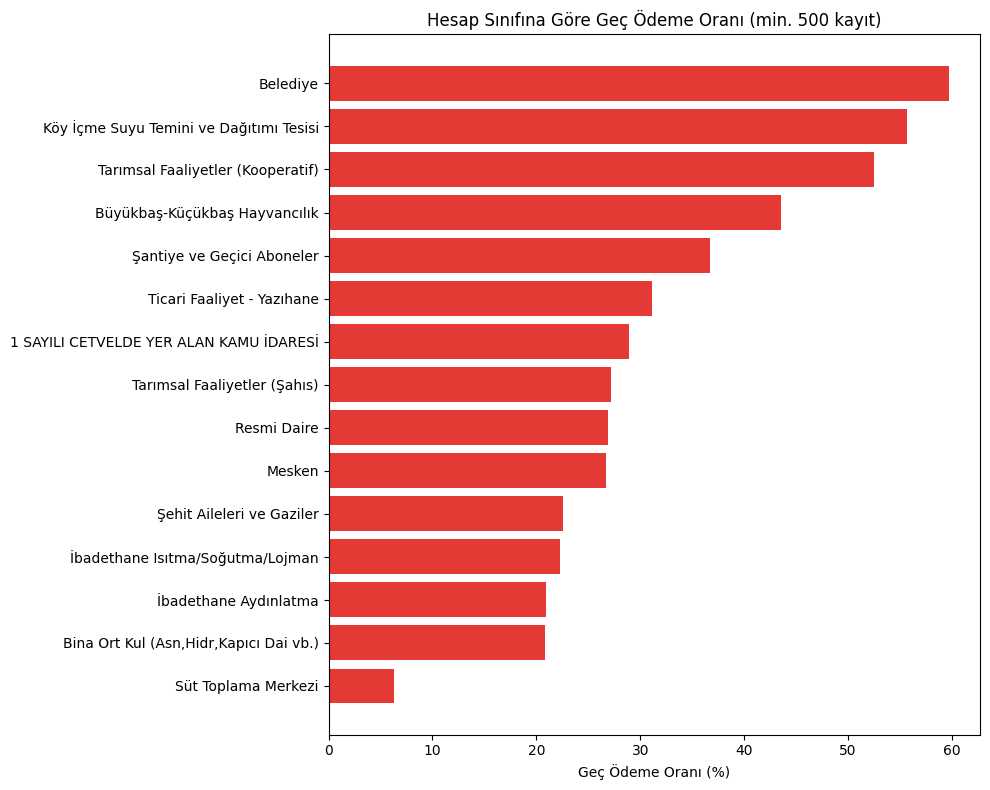

In [26]:
plt.figure(figsize=(10, 8))
hesap_sinifi_gec_sirali = hesap_sinifi_gec.sort_values('mean')
plt.barh(hesap_sinifi_gec_sirali.index, hesap_sinifi_gec_sirali['mean'] * 100, color='#E53935')
plt.xlabel('Geç Ödeme Oranı (%)')
plt.title('Hesap Sınıfına Göre Geç Ödeme Oranı (min. 500 kayıt)')
plt.tight_layout()
plt.savefig('tahsilat_risk_hesap_sinifi.png', dpi=150, bbox_inches='tight')
plt.show()

H1 doğrulandı ve en güçlü etken bu çıktı: Belediye (%59.7) ve Köy İçme Suyu/Tarımsal Kooperatif gibi kamu/tarım hesapları en riskli ödeyiciler. Beklenenin aksine Mesken ortalamanın altında kaldı.

In [27]:
# Hipotez 2: İlçeye göre geç ödeme oranı ne?
ilce_gec = df_tahsilat_1.groupby('İlçe')['gec_mi'].mean()
print(ilce_gec)

İlçe
GÖYNÜCEK        0.307708
GÜMÜŞHACIKÖY    0.247783
HAMAMÖZÜ        0.286746
TAŞOVA          0.277454
Name: gec_mi, dtype: float64


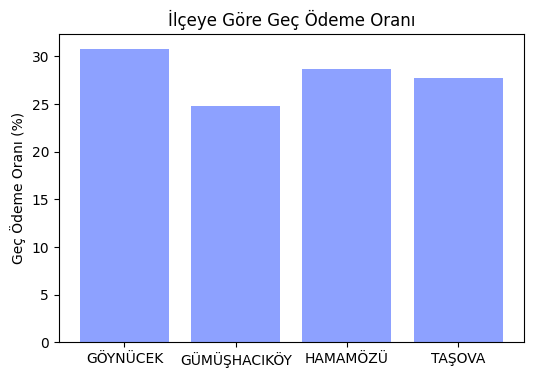

In [28]:
plt.figure(figsize=(6, 4))
plt.bar(ilce_gec.index, ilce_gec.values * 100, color='#8DA1FF')
plt.title('İlçeye Göre Geç Ödeme Oranı')
plt.ylabel('Geç Ödeme Oranı (%)')
plt.savefig('ilce_gec_odeme.png', dpi=150, bbox_inches='tight')
plt.show()

H2 kısmen doğrulandı ama etki küçük: ilçeler arası fark %25 -%30 arasında, hesap sınıfının yanında zayıf kalıyor.

In [29]:
# Hipotez 3: Fatura tutarına göre geç ödeme oranı ne? (tutarı 4 gruba bölüyoruz)
df_tahsilat_1['tutar_grubu'] = pd.qcut(df_tahsilat_1['Tahakkuk Tutar'], q=4, duplicates='drop')
tutar_gec = df_tahsilat_1.groupby('tutar_grubu')['gec_mi'].mean()
print(tutar_gec)

tutar_grubu
(-12793.281, 110.15]    0.290445
(110.15, 202.07]        0.254205
(202.07, 321.57]        0.255519
(321.57, 1173258.44]    0.287355
Name: gec_mi, dtype: float64


/tmp/ipykernel_1778/4103743541.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tutar_gec = df_tahsilat_1.groupby('tutar_grubu')['gec_mi'].mean()


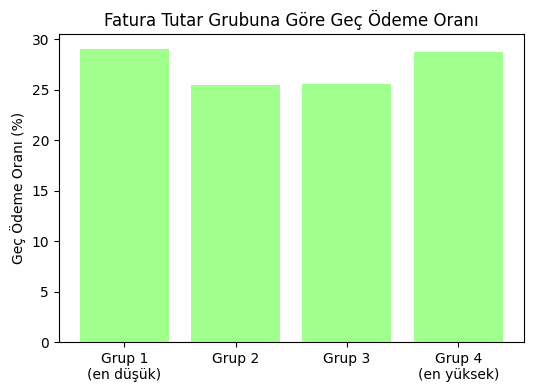

In [30]:
plt.figure(figsize=(6, 4))
tutar_gec_yuzde = tutar_gec * 100
plt.bar(range(len(tutar_gec_yuzde)), tutar_gec_yuzde.values, color='#A1FF8D')
plt.xticks(range(len(tutar_gec_yuzde)), ['Grup 1\n(en düşük)', 'Grup 2', 'Grup 3', 'Grup 4\n(en yüksek)'])
plt.title('Fatura Tutar Grubuna Göre Geç Ödeme Oranı')
plt.ylabel('Geç Ödeme Oranı (%)')
plt.savefig('tutar_gec_odeme.png', dpi=150, bbox_inches='tight')
plt.show()

H3 beklenen gibi çıkmadı: net bir artan trend yok, "U şeklinde" bir örüntü var hem en küçük hem en büyük tutarlı faturalarda geç ödeme oranı orta gruplara göre daha yüksek.

## Genel Değerlendirme

- **Hangi ilçe daha ticari/tarımsal?** Heatmap'e göre Gümüşhacıköy hem ticari (%8.3) hem tarımsal (%1.8) faaliyette
  diğer iki ilçeden daha yüksek pay alıyor. Hamamözü en düşük paya sahip, en "mesken ağırlıklı" ilçe.
- **Eksik veriler rastgele mi?** kwh sütununda hiç eksik yok. Tahsilat 1'deki zamanında/geç ödeme sütunlarındaki boşluklar rastgele değil, sistematik.Her kayıt sadece ödendiği zaman dilimine ait sütunu doldurmuş, diğerleriyapısal olarak boş kalıyor.
- **Bu analizler şirket için nasıl değer yaratıyor?** Bu analizler şirketin riskli müşteri gruplarını önceden görmesine yardımcı oluyor. Böylece tahsilat kaynakları daha çok riskli müşterilere yönlendirilebilir. Ayrıca dönemsel talep değişimleri takip edilerek kapasite planlaması yapılabilir ve düşük riskli müşterilere yönelik sadakat kampanyaları geliştirilebilir.